# 7. Классификация SI > медианы

Ноутбук решает задачу бинарной классификации для показателя `SI`.

In [1]:
# Подключение библиотек

from pathlib import Path
import json
import warnings

from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

random_state = 42
target_columns = ["IC50, mM", "CC50, mM", "SI"]

data_path = Path("/Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/coursework_dataset.csv")
results_dir = Path("/Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results")
figures_dir = results_dir / "figures"
tables_dir = results_dir / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Загрузка данных

dataset = pd.read_csv(data_path)
dataset = dataset.drop(columns=[column for column in dataset.columns if str(column).startswith("Unnamed")], errors="ignore")
dataset = dataset.apply(pd.to_numeric, errors="coerce")
dataset = dataset.drop_duplicates()
dataset = dataset.dropna(subset=target_columns).reset_index(drop=True)

print("Размер датасета после базовой очистки:", dataset.shape)
print(dataset.head())


Размер датасета после базовой очистки: (969, 213)
     IC50, mM    CC50, mM         SI  MaxAbsEStateIndex  MaxEStateIndex  \
0    6.239374  175.482382  28.125000           5.094096        5.094096   
1    0.771831    5.402819   7.000000           3.961417        3.961417   
2  223.808778  161.142320   0.720000           2.627117        2.627117   
3    1.705624  107.855654  63.235294           5.097360        5.097360   
4  107.131532  139.270991   1.300000           5.150510        5.150510   

   MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  ...  \
0           0.387225        0.387225  0.417362  42.928571  384.652  ...   
1           0.533868        0.533868  0.462473  45.214286  388.684  ...   
2           0.543231        0.543231  0.260923  42.187500  446.808  ...   
3           0.390603        0.390603  0.377846  41.862069  398.679  ...   
4           0.270476        0.270476  0.429038  36.514286  466.713  ...   

   fr_sulfide  fr_sulfonamd  fr_sulfone  fr_term

In [3]:
# Подготовка признаков и бинарной целевой переменной

target_column = 'SI'
threshold_setting = 'median'
task_id = 'classification_si_median'

if threshold_setting == "median":
    threshold = float(dataset[target_column].median())
else:
    threshold = float(threshold_setting)

y = (dataset[target_column] > threshold).astype(int)
feature_columns = [column for column in dataset.columns if column not in target_columns]
x = dataset[feature_columns]

print("Целевая переменная:", target_column)
print("Порог классификации:", threshold)
print("Количество признаков:", x.shape[1])
print("Доля положительного класса:", round(float(y.mean()), 3))
print(y.value_counts().rename("count").to_frame())


Целевая переменная: SI
Порог классификации: 3.899999999999999
Количество признаков: 210
Доля положительного класса: 0.499
    count
SI       
0     485
1     484


## Аналитический вывод

Положительный класс соответствует соединениям, у которых SI выше медианы. Такая постановка задачи переводит сложный числовой показатель SI в более устойчивую бинарную задачу.

Классы почти сбалансированы, поэтому снижение качества по сравнению с IC50 и CC50 связано не с дисбалансом классов, а с более сложной природой самого SI.

In [4]:
# Разбиение данных и описание конвейера обучения

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=random_state,
    stratify=y,
)


def make_pipeline(model, scale=False):
    # Конвейер фиксирует одинаковую предобработку для всех моделей.
    # Заполнение пропусков выполняется внутри кросс-валидации.
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
    ]
    if scale:
        steps.append(("scaler", RobustScaler()))
    steps.append(("model", model))
    return Pipeline(steps)


models = {
    "LogisticRegression": (
        make_pipeline(
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="liblinear",
                random_state=random_state,
            ),
            scale=True,
        ),
        {"model__C": [0.1, 1.0, 5.0]},
    ),
    "SVC": (
        make_pipeline(SVC(class_weight="balanced", random_state=random_state), scale=True),
        {"model__C": [1.0, 5.0], "model__gamma": ["scale"]},
    ),
    "RandomForest": (
        make_pipeline(RandomForestClassifier(random_state=random_state, n_jobs=-1, class_weight="balanced"), scale=False),
        {"model__n_estimators": [120], "model__max_depth": [None, 12]},
    ),
    "ExtraTrees": (
        make_pipeline(ExtraTreesClassifier(random_state=random_state, n_jobs=-1, class_weight="balanced"), scale=False),
        {"model__n_estimators": [140], "model__max_depth": [None, 12]},
    ),
    "GradientBoosting": (
        make_pipeline(GradientBoostingClassifier(random_state=random_state), scale=False),
        {"model__n_estimators": [100, 160], "model__learning_rate": [0.05, 0.1]},
    ),
}


def positive_scores(estimator, x_values):
    # ROC-AUC требует не жесткий класс, а числовую оценку принадлежности к положительному классу.
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(x_values)[:, 1]
    return estimator.decision_function(x_values)


In [5]:
# Обучение моделей и подбор гиперпараметров

cross_validation = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
metric_rows = []
fitted_estimators = {}
best_estimator = None
best_roc_auc = -np.inf

for model_name, (model, param_grid) in models.items():
    print("Обучение модели:", model_name)

    search = GridSearchCV(
        model,
        param_grid,
        scoring="roc_auc",
        cv=cross_validation,
        n_jobs=-1,
    )
    search.fit(x_train, y_train)
    fitted_estimators[model_name] = search.best_estimator_

    prediction = search.best_estimator_.predict(x_test)
    score = positive_scores(search.best_estimator_, x_test)
    roc_auc = roc_auc_score(y_test, score)

    metric_rows.append(
        {
            "model": model_name,
            "threshold": threshold,
            "cv_roc_auc": search.best_score_,
            "test_roc_auc": roc_auc,
            "test_accuracy": accuracy_score(y_test, prediction),
            "test_f1": f1_score(y_test, prediction),
            "best_params": json.dumps(search.best_params_, ensure_ascii=False),
        }
    )

    if roc_auc > best_roc_auc:
        best_roc_auc = roc_auc
        best_estimator = search.best_estimator_

metrics = pd.DataFrame(metric_rows).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
metrics_path = tables_dir / f"{task_id}_metrics.csv"
metrics.to_csv(metrics_path, index=False)

print(metrics)
print("Метрики сохранены:", metrics_path)


Обучение модели: LogisticRegression
Обучение модели: SVC
Обучение модели: RandomForest
Обучение модели: ExtraTrees
Обучение модели: GradientBoosting
                model  threshold  cv_roc_auc  test_roc_auc  test_accuracy  \
0    GradientBoosting        3.9    0.708201      0.704751       0.670103   
1  LogisticRegression        3.9    0.653657      0.692475       0.649485   
2        RandomForest        3.9    0.708687      0.685567       0.654639   
3          ExtraTrees        3.9    0.720758      0.682272       0.644330   
4                 SVC        3.9    0.566771      0.598948       0.500000   

    test_f1                                        best_params  
0  0.627907  {"model__learning_rate": 0.05, "model__n_estim...  
1  0.609195                                  {"model__C": 1.0}  
2  0.633880  {"model__max_depth": 12, "model__n_estimators"...  
3  0.618785  {"model__max_depth": 12, "model__n_estimators"...  
4  0.666667         {"model__C": 5.0, "model__gamma": "scale"} 

## Вывод по результатам моделирования

Лучший результат показала модель GradientBoosting: ROC-AUC = 0.705, accuracy = 0.670, F1 = 0.628. Качество выше случайного, но заметно ниже, чем у классификаций IC50 и CC50.

Это подтверждает вывод EDA: SI имеет слабые линейные связи с дескрипторами и сильно зависит от соотношения IC50 и CC50. Даже после перехода к классификации задача остается сложной.

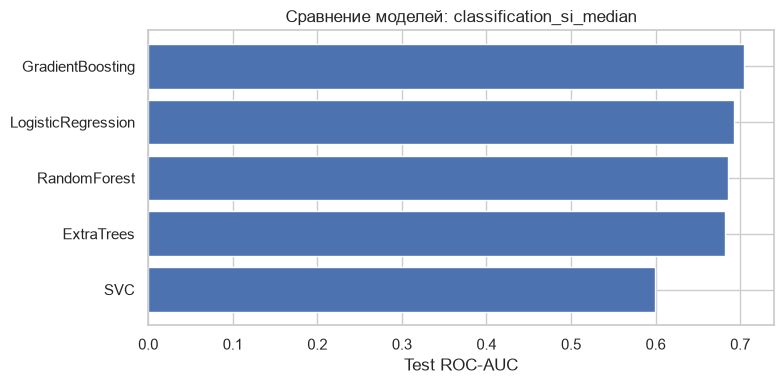

График сохранен: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/figures/classification_si_median_model_comparison.png


In [6]:
# Сравнение моделей по ROC-AUC

plot_data = metrics.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(plot_data["model"], plot_data["test_roc_auc"])
plt.gca().invert_yaxis()
plt.xlabel("Test ROC-AUC")
plt.title(f"Сравнение моделей: {task_id}")
plt.tight_layout()
comparison_path = figures_dir / f"{task_id}_model_comparison.png"
plt.savefig(comparison_path, dpi=160)
plt.show()

print("График сохранен:", comparison_path)


## ROC-кривые нескольких моделей

На одном графике сравниваются ROC-кривые всех обученных моделей. Так проще оценить не только итоговый ROC-AUC из таблицы, но и форму кривой: насколько быстро модель повышает долю верно найденных положительных объектов при росте ложных срабатываний.

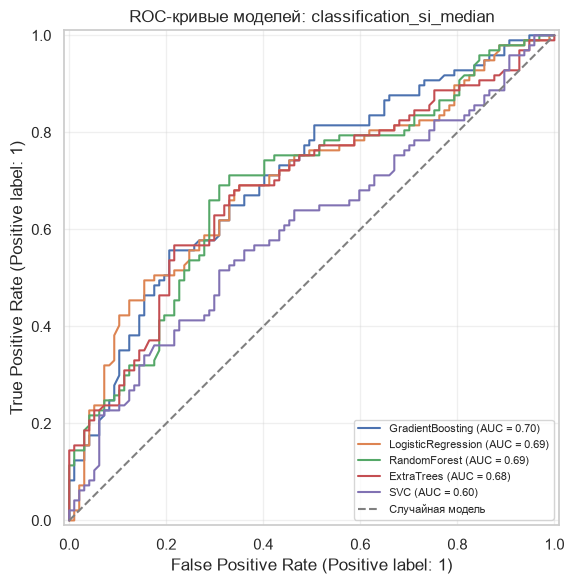

График сохранен: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/figures/classification_si_median_roc_curves.png


In [7]:
# ROC-кривые нескольких моделей

figure, ax = plt.subplots(figsize=(7, 6))

for _, row in metrics.iterrows():
    model_name = row["model"]
    estimator = fitted_estimators[model_name]
    RocCurveDisplay.from_estimator(
        estimator,
        x_test,
        y_test,
        ax=ax,
        name=model_name,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Случайная модель")
ax.set_title(f"ROC-кривые моделей: {task_id}")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()

roc_curves_path = figures_dir / f"{task_id}_roc_curves.png"
plt.savefig(roc_curves_path, dpi=160)
plt.show()

print("График сохранен:", roc_curves_path)

Модель с кривой, расположенной выше остальных, лучше разделяет классы на тестовой выборке. Если несколько кривых близки друг к другу, итоговый выбор модели стоит делать не только по ROC-AUC, но и по F1-score, матрице ошибок и практической цене ложных срабатываний.

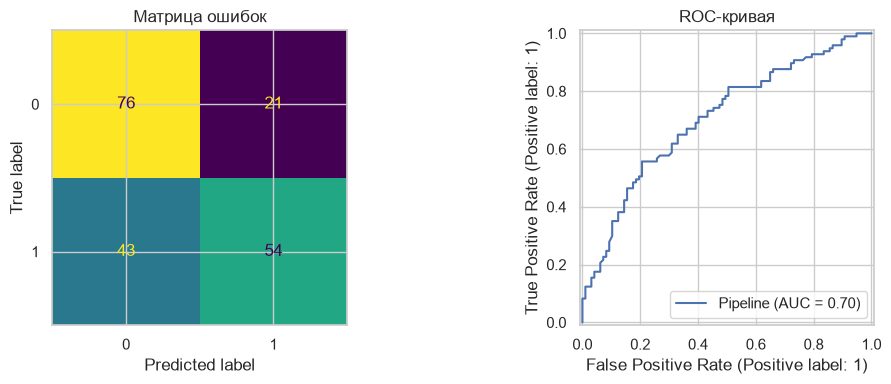

График сохранен: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/figures/classification_si_median_diagnostics.png
Лучшая модель: GradientBoosting


In [8]:
# Диагностика лучшей модели

figure, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_estimator(best_estimator, x_test, y_test, ax=axes[0], colorbar=False)
axes[0].set_title("Матрица ошибок")

RocCurveDisplay.from_estimator(best_estimator, x_test, y_test, ax=axes[1])
axes[1].set_title("ROC-кривая")

plt.tight_layout()
diagnostic_path = figures_dir / f"{task_id}_diagnostics.png"
plt.savefig(diagnostic_path, dpi=160)
plt.show()

print("График сохранен:", diagnostic_path)
print("Лучшая модель:", metrics.loc[0, "model"])


## Итоговый аналитический вывод

Классификация SI относительно медианы дает умеренное качество и может использоваться как вспомогательный инструмент. Для повышения качества стоит попробовать специальные признаки, отражающие соотношения между дескрипторами, а также отдельную обработку соединений с экстремально большими значениями SI.